In [31]:
import os
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns
import networkx as nx

from scipy.sparse.csgraph import minimum_spanning_tree

BASE_DIR = os.path.abspath("..")
DATA_DIR = os.path.join(BASE_DIR, "data")
OUTPUT_DIR = os.path.join(BASE_DIR, "outputs")

os.makedirs(OUTPUT_DIR, exist_ok=True)

print(BASE_DIR)
print(DATA_DIR)
print(OUTPUT_DIR)

/Users/finn/Downloads/Network
/Users/finn/Downloads/Network/data
/Users/finn/Downloads/Network/outputs


In [32]:
sector_2000 = pd.read_csv(
    os.path.join(DATA_DIR, "sector_log_returns_2000.csv"),
    index_col=0,
    parse_dates=True,
)

sector_2018 = pd.read_csv(
    os.path.join(DATA_DIR, "sector_log_returns_2018.csv"),
    index_col=0,
    parse_dates=True,
)

sp500_prices = pd.read_csv(
    os.path.join(DATA_DIR, "SP500_AdjClose_Cleaned.csv"),
    index_col=0,
    parse_dates=True,
)

sector_2000.shape, sector_2018.shape, sp500_prices.shape

((6562, 9), (1919, 11), (6583, 343))

In [33]:
sp500_returns = np.log(sp500_prices / sp500_prices.shift(1)).dropna()
sp500_returns.head()

,HC_A,IT_AAPL,HC_ABT,FIN_ACGL,IT_ADBE,IT_ADI,CST_ADM,UTL_AEE,UTL_AEP,UTL_AES,...,FIN_WFC,IND_WM,CST_WMT,FIN_WRB,CD_WSM,HC_WST,RE_WY,UTL_XEL,CD_YUM,IT_ZBRA
Date,,,,,,,,,,,,,,,,,,,,,
2000-01-04,-0.079464,-0.088077,-0.028987,-0.005450,-0.087618,-0.051913,-0.010472,0.000000,0.011858,-0.040463,...,-0.050789,-0.003604,-0.038136,-0.031253,-0.032026,0.010277,-0.038292,0.022765,-0.020305,-0.014533
2000-01-05,-0.064037,0.014527,-0.001840,0.088831,0.019578,0.014493,-0.015915,0.037956,0.036648,0.010714,...,-0.010136,0.003604,-0.020619,-0.016000,0.005899,-0.004099,0.051619,0.037860,0.005115,0.018963
2000-01-06,-0.038820,-0.090514,0.034392,-0.010050,0.008130,-0.027719,0.005334,-0.003732,0.005666,0.007961,...,0.043197,-0.007221,0.010854,0.056441,-0.223143,-0.010320,0.045718,-0.009331,-0.008539,-0.055665
2000-01-07,0.080043,0.046281,0.010620,0.054067,0.047439,0.027719,0.015831,0.014842,0.013096,0.019198,...,0.017728,-0.040671,0.072845,-0.015361,-0.016683,0.010320,-0.033437,0.000000,-0.022551,-0.011160
2000-01-10,0.058813,-0.017745,-0.007068,0.032944,0.037884,0.083468,0.000000,-0.007395,-0.003724,0.043963,...,-0.032471,0.003766,-0.018417,-0.009332,0.033092,0.020326,-0.004368,0.000000,0.039558,0.033114


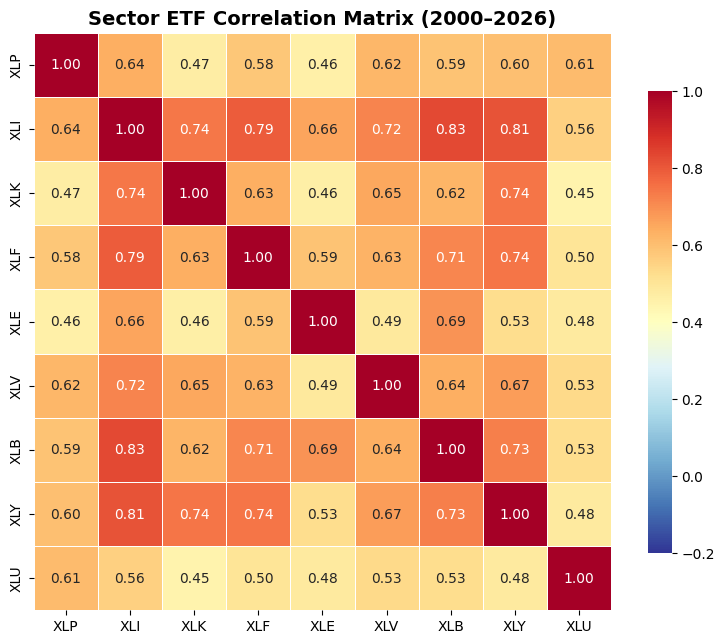

✓ saved fig1_sector_corr_heatmap.png


In [34]:
# Figure 1 — Sector ETF correlation heatmap (full period, 2000–present)

corr_sector_2000 = sector_2000.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    corr_sector_2000,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=-0.2,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)

ax.set_title("Sector ETF Correlation Matrix (2000–2026)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig1_sector_corr_heatmap.png"), dpi=200, bbox_inches="tight")
plt.show()

print("✓ saved fig1_sector_corr_heatmap.png")

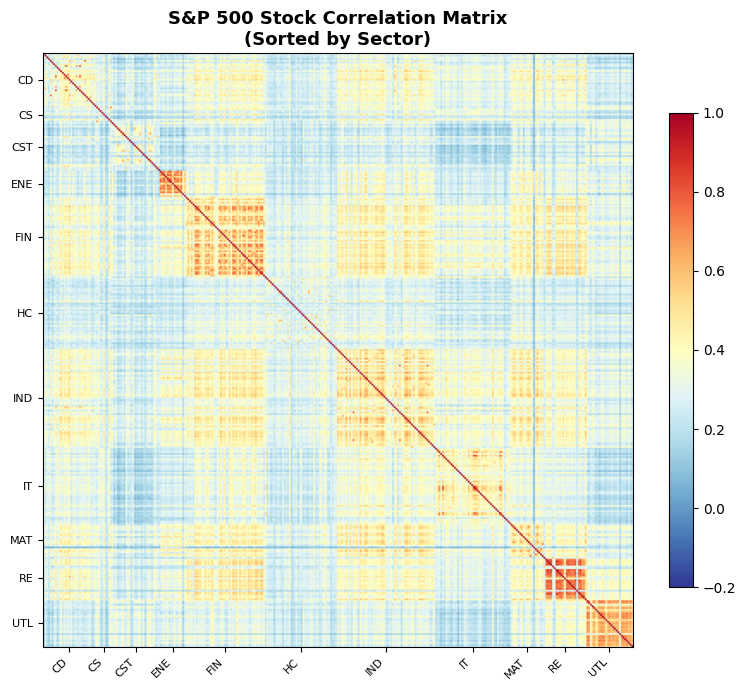

✓ saved fig2_stock_corr_heatmap.png


In [35]:
# Figure 2 — S&P 500 stock correlation heatmap (sorted by sector)
# Appendix

corr_stock = sp500_returns.corr()

# Sort rows/columns by sector prefix so blocks appear on the diagonal
sectors_per_col = [col.split("_")[0] for col in corr_stock.columns]
sort_order = sorted(range(len(sectors_per_col)), key=lambda i: sectors_per_col[i])

corr_sorted = corr_stock.iloc[sort_order, sort_order]
sectors_sorted = [sectors_per_col[i] for i in sort_order]

# Label positions at centre of each sector block
unique_sectors = []
label_positions = []

prev_sector = sectors_sorted[0]
block_start = 0

for i, s in enumerate(sectors_sorted):
    if s != prev_sector:
        unique_sectors.append(prev_sector)
        label_positions.append((block_start + i - 1) / 2)
        block_start = i
        prev_sector = s

# final block
unique_sectors.append(prev_sector)
label_positions.append((block_start + len(sectors_sorted) - 1) / 2)

fig, ax = plt.subplots(figsize=(8, 7))
im = ax.imshow(corr_sorted.values, cmap="RdYlBu_r", vmin=-0.2, vmax=1, aspect="auto")
plt.colorbar(im, ax=ax, shrink=0.8)

ax.set_xticks(label_positions)
ax.set_xticklabels(unique_sectors, fontsize=8, rotation=45, ha="right")
ax.set_yticks(label_positions)
ax.set_yticklabels(unique_sectors, fontsize=8)

ax.set_title("S&P 500 Stock Correlation Matrix\n(Sorted by Sector)", fontsize=13, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig2_stock_corr_heatmap.png"), dpi=200, bbox_inches="tight")
plt.show()

print("✓ saved fig2_stock_corr_heatmap.png")

In [36]:
# Build stock-level MST from price-return correlations

corr_stock_full = sp500_returns.corr()
dist_stock = np.sqrt(2 * (1 - corr_stock_full.clip(-1, 1)))
tickers_stock = corr_stock_full.columns.tolist()

mst_stock_sparse = minimum_spanning_tree(dist_stock.values)
mst_stock_coo = mst_stock_sparse.tocoo()

G_stock_mst = nx.Graph()
G_stock_mst.add_nodes_from(tickers_stock)

for u_idx, v_idx, w in zip(mst_stock_coo.row, mst_stock_coo.col, mst_stock_coo.data):
    G_stock_mst.add_edge(
        tickers_stock[u_idx],
        tickers_stock[v_idx],
        weight=float(w)
    )

degree_counter = dict(G_stock_mst.degree())

print(f"MST nodes: {G_stock_mst.number_of_nodes()}")
print(f"MST edges: {G_stock_mst.number_of_edges()}")

MST nodes: 343
MST edges: 342


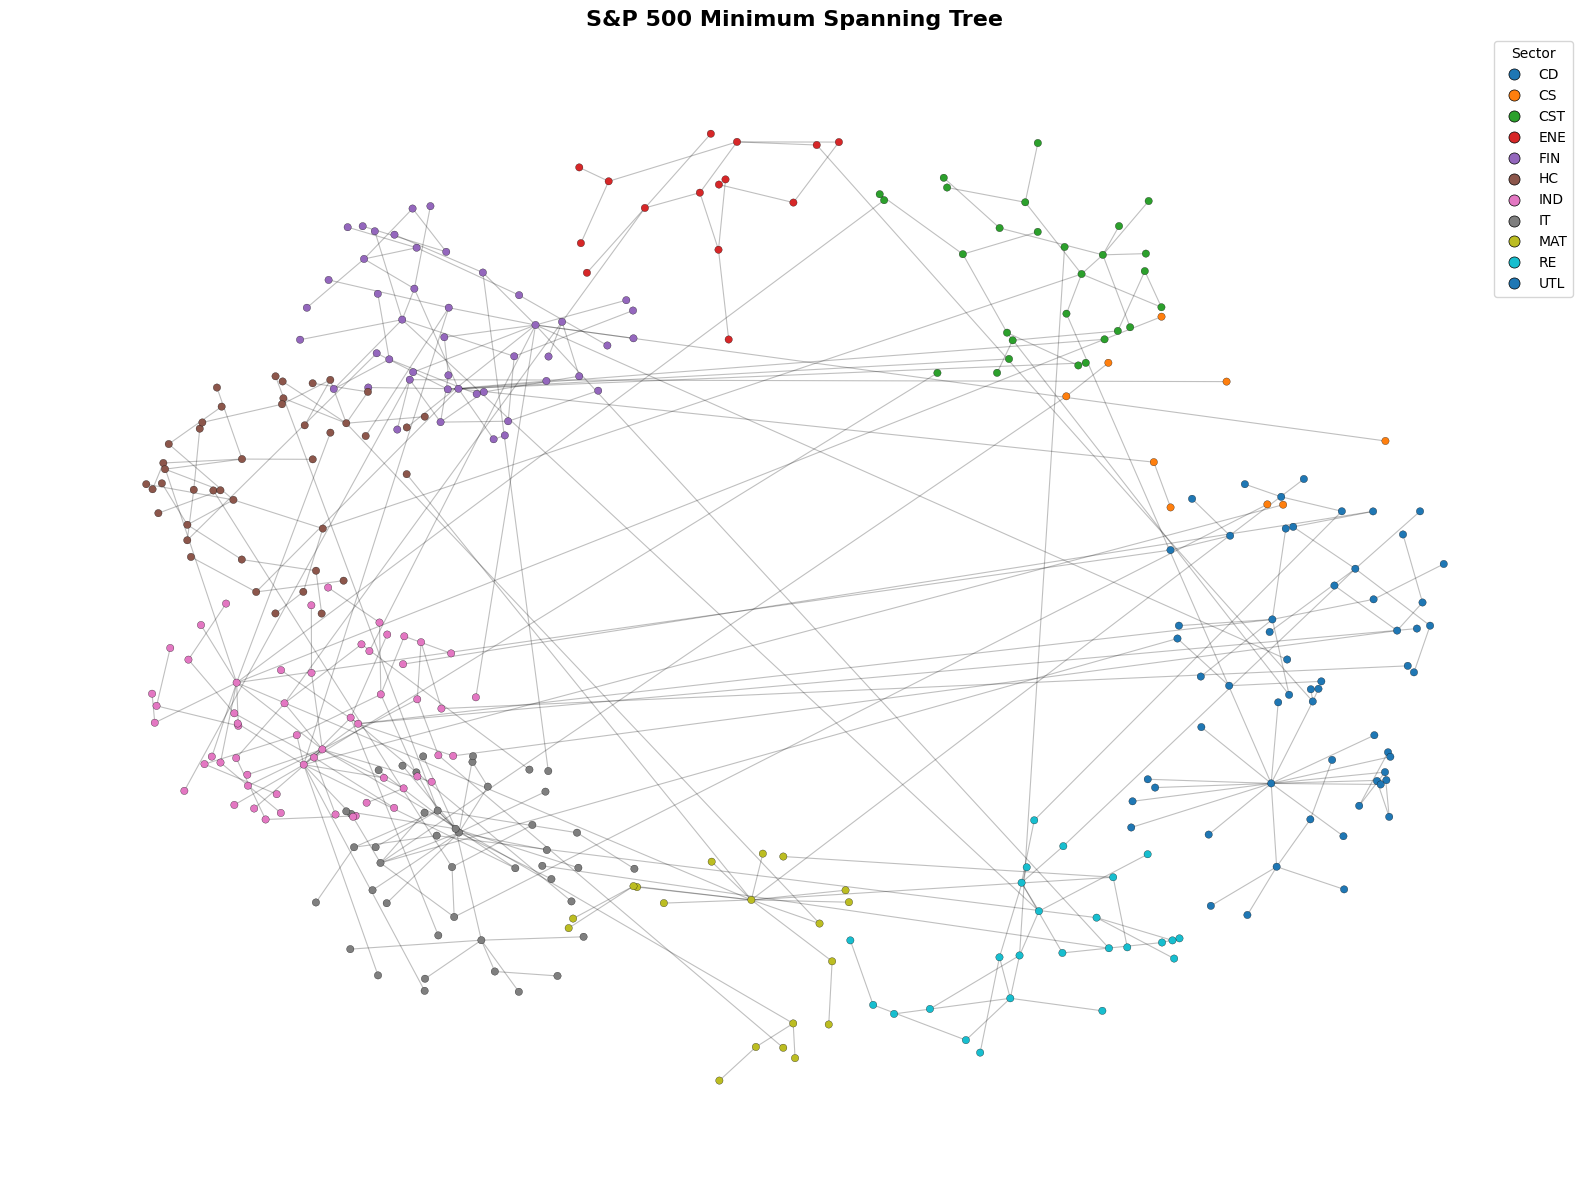

✓ saved fig3_sp500_mst.png


In [37]:
# Figure 3 — S&P 500 MST network

sector_map = {ticker: ticker.split("_")[0] for ticker in G_stock_mst.nodes()}
unique_sector_names = sorted(set(sector_map.values()))

# Fixed centres for each sector so clusters are more visible
sector_centres = {
    s: np.array([
        np.cos(2 * np.pi * i / len(unique_sector_names)),
        np.sin(2 * np.pi * i / len(unique_sector_names))
    ]) * 3.0
    for i, s in enumerate(unique_sector_names)
}

# Base spring layout + sector offsets
pos_base = nx.spring_layout(G_stock_mst, seed=42, k=0.35)
pos = {
    node: pos_base[node] + sector_centres[sector_map[node]]
    for node in G_stock_mst.nodes()
}

# Colours by sector
palette = sns.color_palette("tab10", n_colors=len(unique_sector_names))
sector_palette = dict(zip(unique_sector_names, palette))
node_colors = [sector_palette[sector_map[node]] for node in G_stock_mst.nodes()]

fig, ax = plt.subplots(figsize=(16, 12))

nx.draw_networkx_edges(
    G_stock_mst,
    pos,
    alpha=0.25,
    width=0.8,
    ax=ax
)

nx.draw_networkx_nodes(
    G_stock_mst,
    pos,
    node_size=28,
    node_color=node_colors,
    linewidths=0.2,
    edgecolors="black",
    ax=ax
)

ax.set_title("S&P 500 Minimum Spanning Tree", fontsize=16, fontweight="bold")
ax.axis("off")

handles = [
    plt.Line2D(
        [0], [0],
        marker="o",
        color="w",
        markerfacecolor=sector_palette[s],
        markeredgecolor="black",
        markeredgewidth=0.5,
        markersize=8,
        label=s
    )
    for s in unique_sector_names
]

ax.legend(handles=handles, title="Sector", loc="upper right", frameon=True)

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig3_sp500_mst.png"), dpi=200, bbox_inches="tight")
plt.show()

print("✓ saved fig3_sp500_mst.png")

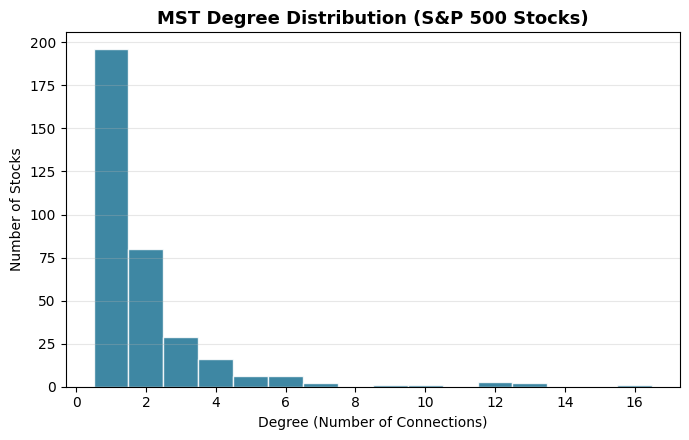

✓ saved fig4_mst_degree_dist.png


In [38]:
# Figure 4 — MST degree distribution

all_degrees = list(degree_counter.values())

fig, ax = plt.subplots(figsize=(7, 4.5))
ax.hist(
    all_degrees,
    bins=range(1, max(all_degrees) + 2),
    color="#1C7293",
    edgecolor="white",
    align="left",
    alpha=0.85
)

ax.set_title("MST Degree Distribution (S&P 500 Stocks)", fontsize=13, fontweight="bold")
ax.set_xlabel("Degree (Number of Connections)")
ax.set_ylabel("Number of Stocks")
ax.grid(True, alpha=0.3, axis="y")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig4_mst_degree_dist.png"), dpi=200, bbox_inches="tight")
plt.show()

print("✓ saved fig4_mst_degree_dist.png")

In [39]:
# Helper table — hub stocks sorted by degree

hub_df = (
    pd.DataFrame({
        "Ticker": list(degree_counter.keys()),
        "Degree": list(degree_counter.values())
    })
    .sort_values("Degree", ascending=False)
    .reset_index(drop=True)
)

hub_df.head(10)

,Ticker,Degree
0,UTL_AEE,16
1,MAT_PPG,13
2,IND_PH,13
3,FIN_TROW,12
4,IND_DOV,12
5,IND_ITW,12
6,IT_CSCO,10
7,FIN_L,9
8,IT_LRCX,7
9,IT_ADI,7


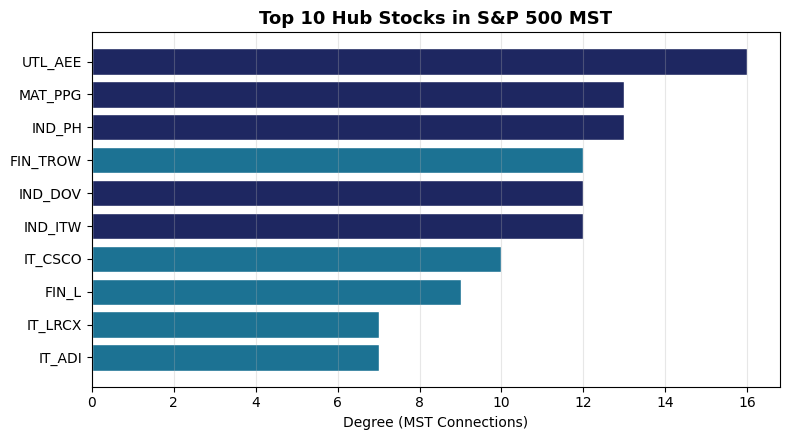

✓ saved fig5_top_hubs.png


In [40]:
# Figure 5 — top 10 hub stocks in the MST

top_hubs = hub_df.head(10).copy()

bar_colors = [
    "#1E2761" if ticker.split("_")[0] in ("IND", "UTL", "MAT") else "#1C7293"
    for ticker in top_hubs["Ticker"]
]

fig, ax = plt.subplots(figsize=(8, 4.5))
ax.barh(
    range(len(top_hubs)),
    top_hubs["Degree"],
    color=bar_colors,
    edgecolor="white"
)

ax.set_yticks(range(len(top_hubs)))
ax.set_yticklabels(top_hubs["Ticker"], fontsize=10)
ax.set_xlabel("Degree (MST Connections)")
ax.set_title("Top 10 Hub Stocks in S&P 500 MST", fontsize=13, fontweight="bold")
ax.invert_yaxis()
ax.grid(True, alpha=0.3, axis="x")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig5_top_hubs.png"), dpi=200, bbox_inches="tight")
plt.show()

print("✓ saved fig5_top_hubs.png")

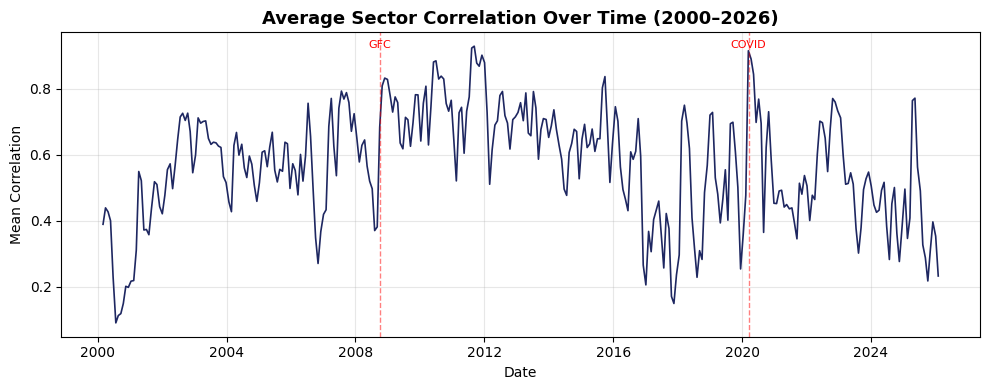

✓ saved fig6_rolling_avg_corr.png


In [41]:
# Figure 6 — Rolling average sector correlation over time

EPOCH_LENGTH = 40   # trading days per window
EPOCH_SHIFT = 20    # overlap shift

mean_corr_values = []
epoch_end_dates = []

for start in range(0, len(sector_2000) - EPOCH_LENGTH, EPOCH_SHIFT):
    epoch = sector_2000.iloc[start:start + EPOCH_LENGTH]
    C = epoch.corr().values

    # Off-diagonal only
    upper_tri = C[np.triu_indices_from(C, k=1)]

    mean_corr_values.append(np.mean(upper_tri))
    epoch_end_dates.append(epoch.index[-1])

fig, ax = plt.subplots(figsize=(10, 4))
ax.plot(epoch_end_dates, mean_corr_values, color="#1E2761", linewidth=1.2)

ax.set_title("Average Sector Correlation Over Time (2000–2026)", fontsize=13, fontweight="bold")
ax.set_ylabel("Mean Correlation")
ax.set_xlabel("Date")
ax.grid(True, alpha=0.3)

for label, date_str in [("GFC", "2008-10-01"), ("COVID", "2020-03-15")]:
    d = pd.Timestamp(date_str)
    if epoch_end_dates[0] <= d <= epoch_end_dates[-1]:
        ax.axvline(d, color="red", linestyle="--", alpha=0.5, linewidth=1)
        ax.text(d, ax.get_ylim()[1] * 0.95, label, fontsize=8, color="red", ha="center")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig6_rolling_avg_corr.png"), dpi=200, bbox_inches="tight")
plt.show()

print("✓ saved fig6_rolling_avg_corr.png")

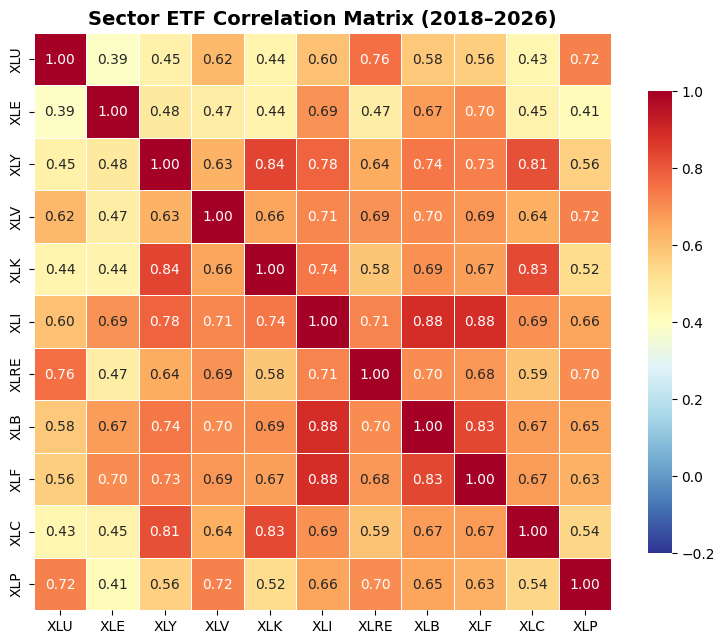

✓ saved fig7_sector_corr_2018.png


In [42]:
# Figure 7 — Sector ETF correlation heatmap (2018–present)
# Appendix

corr_sector_2018 = sector_2018.corr()

fig, ax = plt.subplots(figsize=(8, 6.5))
sns.heatmap(
    corr_sector_2018,
    annot=True,
    fmt=".2f",
    cmap="RdYlBu_r",
    vmin=-0.2,
    vmax=1,
    square=True,
    linewidths=0.5,
    cbar_kws={"shrink": 0.8},
    ax=ax,
)

ax.set_title("Sector ETF Correlation Matrix (2018–2026)", fontsize=14, fontweight="bold")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig7_sector_corr_2018.png"), dpi=200, bbox_inches="tight")
plt.show()

print("✓ saved fig7_sector_corr_2018.png")

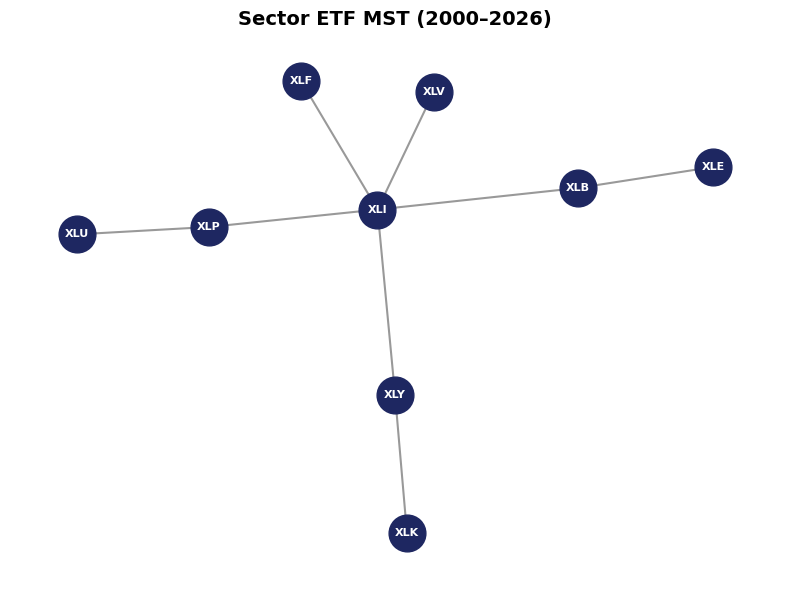

✓ saved fig8_sector_mst.png


In [43]:
# Figure 8 — Sector ETF MST

corr_s = sector_2000.corr()
dist_s = np.sqrt(2 * (1 - corr_s.clip(-1, 1)))
tickers = corr_s.columns.tolist()

mst_sparse = minimum_spanning_tree(dist_s.values)
mst_coo = mst_sparse.tocoo()

G_sector = nx.Graph()
G_sector.add_nodes_from(tickers)

for u_idx, v_idx, w in zip(mst_coo.row, mst_coo.col, mst_coo.data):
    G_sector.add_edge(tickers[u_idx], tickers[v_idx], weight=float(w))

pos = nx.spring_layout(G_sector, seed=42, k=2.0, iterations=200)

fig, ax = plt.subplots(figsize=(8, 6))
nx.draw_networkx_edges(G_sector, pos, ax=ax, width=1.5, alpha=0.4, edge_color="black")
nx.draw_networkx_nodes(G_sector, pos, ax=ax, node_size=700, node_color="#1E2761")
nx.draw_networkx_labels(G_sector, pos, ax=ax, font_size=8, font_color="white", font_weight="bold")

ax.set_title("Sector ETF MST (2000–2026)", fontsize=14, fontweight="bold")
ax.axis("off")

plt.tight_layout()
plt.savefig(os.path.join(OUTPUT_DIR, "fig8_sector_mst.png"), dpi=200, bbox_inches="tight")
plt.show()

print("✓ saved fig8_sector_mst.png")